In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report,\
roc_auc_score, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter("ignore")
import xgboost as xgb
import joblib
import os
from google.colab import drive
from xgboost import plot_importance
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
print(xgb.__version__)

RANDOM_STATE_SEED = 12

3.2.0


In [ ]:
%cd /content/drive/MyDrive/CIC-IDS-2018-data

/content/drive/MyDrive/CIC-IDS-2018-data


Section 1: Data View and Loading



In [ ]:
#reading the dataset
df1= pd.read_csv("/content/drive/MyDrive/CIC-IDS-2018-data/02-14-2018.csv",low_memory=True)
df2= pd.read_csv("/content/drive/MyDrive/CIC-IDS-2018-data/02-15-2018.csv",low_memory=True)

In [ ]:
data_list = [df1, df2]
print('Data dimensions: ')
for i, df in enumerate(data_list, start = 1):
  rows, cols = df.shape
  print(f'Data{i} -> {rows} rows, {cols} columns')

Data dimensions: 
Data1 -> 1048575 rows, 80 columns
Data2 -> 1048575 rows, 80 columns


In [ ]:
df_dataset = pd.concat(data_list)
rows, cols = df.shape
print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')
df_dataset

New dimension:
Number of rows: 1048575
Number of columns: 80
Total cells: 83886000


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,50111,6,15/02/2018 09:04:42,22,3,0,31,0,31,0,...,20,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
1048571,443,6,15/02/2018 09:03:55,54682783,5,1,123,46,46,0,...,20,158783.0,0.000000,158783,158783,54523813.0,0.000000,54523813,54523813,Benign
1048572,443,6,15/02/2018 09:03:56,53682093,5,1,123,46,46,0,...,20,259719.0,0.000000,259719,259719,53421756.0,0.000000,53421756,53421756,Benign
1048573,443,6,15/02/2018 09:03:55,54683364,5,1,123,46,46,0,...,20,158870.0,0.000000,158870,158870,54523593.0,0.000000,54523593,54523593,Benign


In [ ]:
df_dataset.dtypes

,0
Dst Port,int64
Protocol,int64
Timestamp,object
Flow Duration,int64
Tot Fwd Pkts,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,int64
Idle Min,int64


In [ ]:
#striping the spaces if any exists
column_names = {col:col.strip() for col in df_dataset.columns}
#renaming the columns
df_dataset.rename(columns = column_names, inplace=True)
#displaying the columns if any change occured or not
df_dataset.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [ ]:
df_dataset.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,...,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06,2.097150e+06
mean,6.134380e+03,8.813011e+00,1.028147e+07,5.676310e+00,6.815488e+00,4.417099e+02,4.723844e+03,1.630066e+02,1.118473e+01,4.176076e+01,...,2.337895e+00,1.993505e+01,8.188203e+04,3.486536e+04,1.348432e+05,6.158000e+04,3.724341e+06,4.977859e+05,4.714533e+06,3.118095e+06
std,1.611496e+04,4.950855e+00,8.914813e+08,3.950497e+01,1.014267e+02,2.321434e+04,1.458393e+05,2.828337e+02,2.194242e+01,5.711160e+01,...,5.625452e+00,1.001594e+01,7.855725e+05,3.086169e+05,1.000943e+06,7.307746e+05,3.830152e+08,2.701221e+08,1.076350e+09,1.624343e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,6.000000e+00,1.080000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,3.907000e+03,2.000000e+00,1.000000e+00,4.100000e+01,7.400000e+01,3.900000e+01,0.000000e+00,3.384615e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.450000e+02,1.700000e+01,1.783384e+06,6.000000e+00,4.000000e+00,3.640000e+02,4.880000e+02,1.610000e+02,3.000000e+01,5.366667e+01,...,3.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,9.021000e+03,1.918100e+04,8.737314e+06,2.790523e+07,6.444000e+04,1.460000e+03,1.652931e+04,...,1.468000e+03,5.600000e+01,1.119924e+08,6.017711e+07,1.119924e+08,1.119924e+08,3.394503e+11,2.432682e+11,9.797810e+11,1.260300e+10


In [ ]:
# feature information
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097150 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           int64  
 2   Timestamp          object 
 3   Flow Duration      int64  
 4   Tot Fwd Pkts       int64  
 5   Tot Bwd Pkts       int64  
 6   TotLen Fwd Pkts    int64  
 7   TotLen Bwd Pkts    int64  
 8   Fwd Pkt Len Max    int64  
 9   Fwd Pkt Len Min    int64  
 10  Fwd Pkt Len Mean   float64
 11  Fwd Pkt Len Std    float64
 12  Bwd Pkt Len Max    int64  
 13  Bwd Pkt Len Min    int64  
 14  Bwd Pkt Len Mean   float64
 15  Bwd Pkt Len Std    float64
 16  Flow Byts/s        float64
 17  Flow Pkts/s        float64
 18  Flow IAT Mean      float64
 19  Flow IAT Std       float64
 20  Flow IAT Max       int64  
 21  Flow IAT Min       int64  
 22  Fwd IAT Tot        int64  
 23  Fwd IAT Mean       float64
 24  Fwd IAT Std        float64
 25  Fwd IAT Max        int6

Section 2: Data cleaning

Remove Duplicates

In [ ]:
#printing how many duplicate records exists in dataframe
Duplicates = df_dataset[df_dataset.duplicated]
print(len(Duplicates)) #2633
df_dataset.shape

228049


(2097150, 80)

In [ ]:
#dropping the duplicate records from the dataset
df_dataset.drop_duplicates(inplace=True)
df_dataset.shape

(1869101, 80)

Handling Missing Values



In [ ]:
#missing Value checking
missing_value = df_dataset.isna().sum()
print(missing_value.loc[missing_value>0])

Flow Byts/s    7198
dtype: int64


In [ ]:
#checking numeric columns
numeric_columns = df_dataset.select_dtypes(include=[np.number]).columns
#checking infinity count in dataset
infinity_count = np.isinf(df_dataset[numeric_columns]).sum()
print(infinity_count[infinity_count>0])

Flow Byts/s     4645
Flow Pkts/s    11843
dtype: int64


In [ ]:
# replace +ve and -ve infinity with NaN
df_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
df_dataset.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,...,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06,1.869101e+06
mean,6.879998e+03,9.155527e+00,1.152628e+07,6.245202e+00,7.526517e+00,4.955954e+02,5.300195e+03,1.828883e+02,1.254292e+01,4.684937e+01,...,2.623052e+00,1.782399e+01,9.187246e+04,3.911928e+04,1.512954e+05,6.909338e+04,4.169144e+06,5.585207e+05,5.280150e+06,3.488930e+06
std,1.691920e+04,5.139542e+00,9.442933e+08,4.181003e+01,1.074146e+02,2.458924e+04,1.544704e+05,2.934617e+02,2.286783e+01,5.849154e+01,...,5.895671e+00,8.329846e+00,8.315658e+05,3.266478e+05,1.059074e+06,7.737374e+05,4.057054e+08,2.861267e+08,1.140122e+09,1.714045e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,6.000000e+00,3.680000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,3.768200e+04,2.000000e+00,1.000000e+00,4.600000e+01,1.070000e+02,4.200000e+01,0.000000e+00,3.725000e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.450000e+02,1.700000e+01,2.447722e+06,7.000000e+00,6.000000e+00,4.550000e+02,8.600000e+02,2.280000e+02,3.200000e+01,5.900000e+01,...,4.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,9.021000e+03,1.918100e+04,8.737314e+06,2.790523e+07,6.444000e+04,1.460000e+03,1.652931e+04,...,1.468000e+03,5.600000e+01,1.119924e+08,6.017711e+07,1.119924e+08,1.119924e+08,3.394503e+11,2.432682e+11,9.797810e+11,1.260300e+10


In [ ]:
# drop missing values
df_dataset.dropna(inplace=True)
df_dataset

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,50111,6,15/02/2018 09:04:42,22,3,0,31,0,31,0,...,20,0.0,0.000000,0,0,0.0,0.000000,0,0,Benign
1048571,443,6,15/02/2018 09:03:55,54682783,5,1,123,46,46,0,...,20,158783.0,0.000000,158783,158783,54523813.0,0.000000,54523813,54523813,Benign
1048572,443,6,15/02/2018 09:03:56,53682093,5,1,123,46,46,0,...,20,259719.0,0.000000,259719,259719,53421756.0,0.000000,53421756,53421756,Benign
1048573,443,6,15/02/2018 09:03:55,54683364,5,1,123,46,46,0,...,20,158870.0,0.000000,158870,158870,54523593.0,0.000000,54523593,54523593,Benign


**Analysing**

In [ ]:
#unique Values
df_dataset['Label'].unique()

array(['Benign', 'FTP-BruteForce', 'SSH-Bruteforce',
       'DoS attacks-GoldenEye', 'DoS attacks-Slowloris'], dtype=object)

In [ ]:
#count of unique values
df_dataset['Label'].value_counts()

,count
Label,
Benign,1648850
SSH-Bruteforce,117322
DoS attacks-GoldenEye,41455
FTP-BruteForce,39346
DoS attacks-Slowloris,10285


In [ ]:
# Creating a dictionary that maps each label to its attack type
attack_map = {
    'Benign': 'BENIGN',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force',
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df_dataset['Attack Type'] = df_dataset['Label'].map(attack_map)

Since our goal is binary classification ("attack" vs "not attack"), we can group FTP/SSH brute force and DoS attacks under one name instead of keeping them separate. Let's name them "Malicious".

In [ ]:
df_dataset['Attack'] = df_dataset['Attack Type'].replace(to_replace=["Brute Force", "DoS"], value="Malicious")
df_dataset['Attack'].value_counts()

,count
Attack,
BENIGN,1648850
Malicious,208408


In [ ]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)
import plotly.graph_objs as go
fig = go.Figure(data=[
    go.Bar(name='Benign',
           y=df["Label"].value_counts().values[0:1],
           x=['Benign'],
           text = df["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',),
    go.Bar(name='Malicious',
           y=df["Label"].value_counts().values[1:2],
           x=['Malicious'],
           text = df["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

To prevent our classification model from being biased, we should make sure that the class distribution is even (i.e. 50% benign and 50% malicious).

Since there are 208408 instances of Malicious and 1648850 instances of Benign, we can take 208408
instances of both Malicious and Benign to train our model with an even class distribution.

In [ ]:
df_train1 = df_dataset[df_dataset['Attack'] == "BENIGN"][:208408]
df_train2 = df_dataset[df_dataset['Attack'] == "Malicious"][:208408]
df_equal = pd.concat([ df_train1,df_train2], axis =0)

Implementing binary classification

In [ ]:
# We now encode our class labels to integer values for the model to use.
df_equal['Attack'] = df_equal['Attack'].replace(to_replace="BENIGN", value=0)
df_equal['Attack'] = df_equal['Attack'].replace(to_replace="Malicious", value=1)

Train/Test Split

In [ ]:
train, test = train_test_split(df_equal, test_size=0.2, random_state=RANDOM_STATE_SEED)

In [ ]:
# display columns
train.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [ ]:
# feature info
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333452 entries, 91566 to 131744
Data columns (total 82 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           333452 non-null  int64  
 1   Protocol           333452 non-null  int64  
 2   Timestamp          333452 non-null  object 
 3   Flow Duration      333452 non-null  int64  
 4   Tot Fwd Pkts       333452 non-null  int64  
 5   Tot Bwd Pkts       333452 non-null  int64  
 6   TotLen Fwd Pkts    333452 non-null  int64  
 7   TotLen Bwd Pkts    333452 non-null  int64  
 8   Fwd Pkt Len Max    333452 non-null  int64  
 9   Fwd Pkt Len Min    333452 non-null  int64  
 10  Fwd Pkt Len Mean   333452 non-null  float64
 11  Fwd Pkt Len Std    333452 non-null  float64
 12  Bwd Pkt Len Max    333452 non-null  int64  
 13  Bwd Pkt Len Min    333452 non-null  int64  
 14  Bwd Pkt Len Mean   333452 non-null  float64
 15  Bwd Pkt Len Std    333452 non-null  float64
 16  Flo

Feature Scaling

In [ ]:
min_max_scaler = MinMaxScaler().fit(train[['Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg',
       'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg',
       'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
       'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts',
       'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max',
       'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']])

In [ ]:
numerical_columns = ['Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg',
       'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg',
       'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
       'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts',
       'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max',
       'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

In [ ]:
train[numerical_columns] = min_max_scaler.transform(train[numerical_columns])
train

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack Type,Attack
91566,21,6,14/02/2018 11:19:22,0.999869,0.000000,0.000112,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,FTP-BruteForce,Brute Force,1
432556,80,6,14/02/2018 11:49:36,0.999920,0.001426,0.001006,0.000051,0.000136,0.006688,0.000000,...,0.000825,0.001547,0.000861,0.000030,1.172456e-08,0.000011,0.000794,Benign,BENIGN,0
213071,22,6,14/02/2018 02:24:46,0.999870,0.004279,0.002460,0.000232,0.000205,0.009932,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,SSH-Bruteforce,Brute Force,1
425470,53,17,14/02/2018 08:30:07,0.999869,0.000000,0.000112,0.000004,0.000004,0.000590,0.032313,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
484818,53,17,14/02/2018 12:19:02,0.999869,0.000000,0.000112,0.000004,0.000007,0.000512,0.028061,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417700,53,17,14/02/2018 11:10:27,0.999869,0.000000,0.000112,0.000009,0.000016,0.001195,0.065476,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
421420,80,6,14/02/2018 12:22:57,0.999876,0.000611,0.000447,0.000011,0.000018,0.001505,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
50250,80,6,15/02/2018 11:06:16,0.999986,0.002852,0.000335,0.000295,0.000000,0.003569,0.000000,...,0.036342,0.094747,0.132168,0.000071,8.691258e-05,0.000056,0.000528,DoS attacks-Slowloris,DoS,1
189998,22,6,14/02/2018 02:11:58,0.999870,0.004279,0.002460,0.000223,0.000205,0.009932,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,SSH-Bruteforce,Brute Force,1


In [ ]:
train.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
count,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,...,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000,333452.000000
mean,3731.693056,7.608651,0.999873,0.001570,0.001008,0.000089,0.000289,0.004134,0.005601,0.004713,...,0.517322,0.002975,0.000755,0.002062,0.002585,0.000016,0.000007,0.000010,0.000264,0.499388
std,12745.847992,4.014280,0.002376,0.006930,0.009773,0.002751,0.009658,0.005100,0.015615,0.005387,...,0.208991,0.020072,0.005739,0.012892,0.018805,0.002275,0.002231,0.002213,0.002140,0.500000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,6.000000,0.999869,0.000000,0.000112,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,6.000000,0.999870,0.000407,0.000224,0.000011,0.000014,0.000854,0.000000,0.003923,...,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,6.000000,0.999872,0.003056,0.001789,0.000213,0.000205,0.009932,0.000000,0.007813,...,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,65530.000000,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333452 entries, 91566 to 131744
Data columns (total 82 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           333452 non-null  int64  
 1   Protocol           333452 non-null  int64  
 2   Timestamp          333452 non-null  object 
 3   Flow Duration      333452 non-null  float64
 4   Tot Fwd Pkts       333452 non-null  float64
 5   Tot Bwd Pkts       333452 non-null  float64
 6   TotLen Fwd Pkts    333452 non-null  float64
 7   TotLen Bwd Pkts    333452 non-null  float64
 8   Fwd Pkt Len Max    333452 non-null  float64
 9   Fwd Pkt Len Min    333452 non-null  float64
 10  Fwd Pkt Len Mean   333452 non-null  float64
 11  Fwd Pkt Len Std    333452 non-null  float64
 12  Bwd Pkt Len Max    333452 non-null  float64
 13  Bwd Pkt Len Min    333452 non-null  float64
 14  Bwd Pkt Len Mean   333452 non-null  float64
 15  Bwd Pkt Len Std    333452 non-null  float64
 16  Flo

In [ ]:
test[numerical_columns] = min_max_scaler.transform(test[numerical_columns])
test

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack Type,Attack
201476,22,6,14/02/2018 02:19:11,0.999870,0.004279,0.002348,0.000227,0.000205,0.009932,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,SSH-Bruteforce,Brute Force,1
38654,80,6,15/02/2018 09:56:15,0.999871,0.000204,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,DoS attacks-GoldenEye,DoS,1
477375,53,17,14/02/2018 03:22:18,0.999870,0.000204,0.000224,0.000012,0.000025,0.000791,0.043367,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
467660,443,6,14/02/2018 01:09:19,0.999936,0.003260,0.001901,0.000172,0.000698,0.011437,0.000000,...,0.005187,0.010034,0.002392,0.00003,5.287723e-07,0.000011,0.000769,Benign,BENIGN,0
27832,80,6,15/02/2018 09:56:48,0.999882,0.001834,0.000447,0.000336,0.000051,0.006378,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,DoS attacks-GoldenEye,DoS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585301,53,17,14/02/2018 02:28:49,0.999869,0.000000,0.000112,0.000005,0.000004,0.000621,0.034014,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
3712,80,6,15/02/2018 09:30:36,0.999875,0.000611,0.000447,0.000044,0.000051,0.005788,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,DoS attacks-GoldenEye,DoS,1
423461,53,17,14/02/2018 12:08:17,0.999870,0.000204,0.000224,0.000010,0.000009,0.000683,0.037415,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0
568503,53,17,14/02/2018 12:28:08,0.999870,0.000204,0.000224,0.000008,0.000008,0.000512,0.028061,...,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,Benign,BENIGN,0


In [ ]:
test.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
count,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,...,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000,83364.000000
mean,3683.582494,7.608548,0.999877,0.001560,0.001009,0.000092,0.000288,0.004141,0.005582,0.004699,...,0.518093,0.003067,0.000750,0.002109,0.002701,0.000023,0.000014,0.000017,0.000271,0.502447
std,12669.526618,4.016330,0.001032,0.006228,0.010213,0.003474,0.010093,0.005254,0.015836,0.005326,...,0.209227,0.020734,0.005413,0.012989,0.019894,0.003523,0.003544,0.003578,0.002385,0.499997
min,0.000000,0.000000,0.701925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,6.000000,0.999869,0.000000,0.000112,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,6.000000,0.999870,0.000407,0.000224,0.000011,0.000014,0.000854,0.000000,0.003923,...,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,80.000000,6.000000,0.999872,0.003056,0.001789,0.000223,0.000205,0.009932,0.000000,0.007813,...,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,65520.000000,17.000000,1.000000,1.006520,1.015541,1.002674,1.014359,0.733333,1.241497,0.735772,...,0.833333,1.247433,0.365176,0.624320,1.411982,1.017063,1.023203,1.033055,0.615568,1.000000


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83364 entries, 201476 to 274475
Data columns (total 82 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dst Port           83364 non-null  int64  
 1   Protocol           83364 non-null  int64  
 2   Timestamp          83364 non-null  object 
 3   Flow Duration      83364 non-null  float64
 4   Tot Fwd Pkts       83364 non-null  float64
 5   Tot Bwd Pkts       83364 non-null  float64
 6   TotLen Fwd Pkts    83364 non-null  float64
 7   TotLen Bwd Pkts    83364 non-null  float64
 8   Fwd Pkt Len Max    83364 non-null  float64
 9   Fwd Pkt Len Min    83364 non-null  float64
 10  Fwd Pkt Len Mean   83364 non-null  float64
 11  Fwd Pkt Len Std    83364 non-null  float64
 12  Bwd Pkt Len Max    83364 non-null  float64
 13  Bwd Pkt Len Min    83364 non-null  float64
 14  Bwd Pkt Len Mean   83364 non-null  float64
 15  Bwd Pkt Len Std    83364 non-null  float64
 16  Flow Byts/s        83

Counting number of records in each split

In [ ]:
print("Full dataset:\n")
print("Benign: " + str(df_equal["Attack"].value_counts()[[0]].sum()))
print("Malicious: " + str(df_equal["Attack"].value_counts()[[1]].sum()))
print("---------------")

print("Training set:\n")
print("Benign: " + str(train["Attack"].value_counts()[[0]].sum()))
print("Malicious: " + str(train["Attack"].value_counts()[[1]].sum()))
print("---------------")

print("Test set:\n")
print("Benign: " + str(test["Attack"].value_counts()[[0]].sum()))
print("Malicious: " + str(test["Attack"].value_counts()[[1]].sum()))

Full dataset:

Benign: 208408
Malicious: 208408
---------------
Training set:

Benign: 166930
Malicious: 166522
---------------
Test set:

Benign: 41478
Malicious: 41886


Creating X,Y variables

In [ ]:
# Define features (X) and target (y)
feature_columns = [col for col in train.columns if col not in ["Timestamp", "Label", "Attack Type", "Attack"]]
X_train = train[feature_columns].values
y_train = train["Attack"].values

print(type(X_train))
print(type(y_train))
print(X_train.shape)
print(y_train.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(333452, 78)
(333452,)


In [ ]:
# Define features (X) and target (y)
feature_columns_test = [col for col in test.columns if col not in ["Timestamp", "Label", "Attack Type", "Attack"]]
X_test = test[feature_columns_test].values
y_test = test["Attack"].values

print(type(X_test))
print(type(y_test))
print(X_test.shape)
print(y_test.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(83364, 78)
(83364,)


Perform XGBoosting Classifier

In [ ]:
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score

model = xgb.XGBClassifier(objective='binary:logistic',  # Specify objective for classification
                          n_estimators=100,            # Number of boosting rounds (trees)
                          learning_rate=0.1,           # Learning rate
                          max_depth=5)                 # Maximum tree depth

# Train the model
model.fit(X_train,y_train)

# Make predictions on the testing set
y_predict =model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_predict)
y_true = y_test

print('========XGBoost Classifier-Prediction result========')
print('Accuaracy of XGBoost : ',accuracy)
precision,recall,fscore,none =precision_recall_fscore_support(y_true,y_predict,average='weighted')
print('Precision of XGBoost : ',precision)
print('Recall of XGBoost : ',recall)
print('f1-score of XGBoost : ',fscore)
print(classification_report(y_true,y_predict))

========XGBoost Classifier-Prediction result========
Accuaracy of XGBoost :  0.9999640132431266
Precision of XGBoost :  0.9999640158204206
Recall of XGBoost :  0.9999640132431266
f1-score of XGBoost :  0.9999640132367416
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41478
           1       1.00      1.00      1.00     41886

    accuracy                           1.00     83364
   macro avg       1.00      1.00      1.00     83364
weighted avg       1.00      1.00      1.00     83364



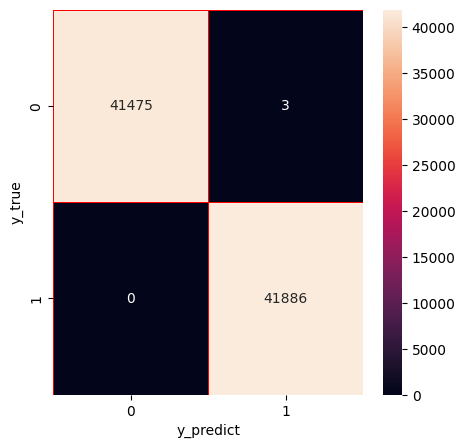

In [ ]:
cn = confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cn,annot=True, linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_predict")
plt.ylabel("y_true")
plt.show()

Grid Search

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 8],
}
# Perform Grid Search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

# Access Best Parameters and Model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Use the best_model for predictions and evaluation on the testing set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with Optimized Hyperparameters:", accuracy)

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150}
Accuracy with Optimized Hyperparameters: 1.0


Random Search

In [ ]:
from scipy.stats import randint,uniform
param_dist = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.5),
    'max_depth': randint(3, 10),
}
# Perform Randomized Search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   scoring='accuracy', n_iter=100)
random_search.fit(X_train, y_train)

# Access Best Parameters and Model
best_params = random_search.best_params_
best_model = random_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Use the best_model for predictions and evaluation on the testing set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with Optimized Hyperparameters:", accuracy)

Best Hyperparameters: {'learning_rate': np.float64(0.43514106175493966), 'max_depth': 3, 'n_estimators': 101}
Accuracy with Optimized Hyperparameters: 1.0


In [ ]:
print((best_model))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.43514106175493966), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=101, n_jobs=None,
              num_parallel_tree=None, ...)


Export

In [ ]:
# Install necessary packages
!pip install -U sklearn2pmml
!apt-get update # Added to refresh package lists and potentially resolve 404
!apt-get install -y default-jdk

import pandas as pd
from xgboost import XGBClassifier
from sklearn2pmml import sklearn2pmml
from sklearn2pmml.pipeline import PMMLPipeline
import joblib
import os

# X_train (numpy array) and y_train (numpy array) are already defined in previous cells.
# feature_columns (list of strings) is also defined in previous cells and contains the correct column names.
full_columns = ['Dst Port',
        'Protocol','Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg',
       'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg',
       'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
       'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts',
       'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max',
       'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']
# Reconstruct X_train as a DataFrame with column names for sklearn2pmml
X_train_df_for_pmml = pd.DataFrame(X_train, columns=full_columns)

# Use the best_model which was already trained in the previous cells (from RandomizedSearchCV)
trained_model = best_model

# The prints below refer to the trained_model and feature_columns
print(f"Model classes: {trained_model.classes_}")      # should be [0 1]
print(f"Number of classes: {trained_model.n_classes_}")    # should be 2
print(f"Number of feature columns: {len(full_columns)}") # Using feature_columns from earlier definitions
print(f"Number of features in model: {trained_model.n_features_in_}")

pipeline = PMMLPipeline([
    ("classifier", trained_model)
])
pipeline.active_fields = np.array(full_columns)
# Export directly after training
sklearn2pmml(
    pipeline,
    "/content/drive/MyDrive/do_an_3_remake/xgb_model.pmml",
    with_repr=True
)

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/do_an_3_remake'

if not os.path.exists(save_path):
    os.makedirs(save_path)

try:
    joblib.dump(best_model, os.path.join(save_path, 'xgboost_model.pkl'))
    joblib.dump(min_max_scaler, os.path.join(save_path, 'scaler.pkl'))
    print(f"Saved model and scaler in: {save_path}")

except NameError as e:
    print(f"Loi: {e}")

import joblib
scaler = joblib.load("/content/drive/MyDrive/do_an_3_remake/scaler.pkl")
feature_names = scaler.feature_names_in_

joblib.dump(feature_names, os.path.join(save_path, "feature_name.pkl"))

print("✅ feature_names.pkl created")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved model and scaler in: /content/drive/MyDrive/do_an_3_remake
✅ feature_names.pkl created
